# Vježba 8 — Zadatak: MLP na Spotify datasetu

Dataset:
https://www.kaggle.com/datasets/solomonameh/spotify-music-dataset?resource=download

Cilj: Binarna klasifikacija — na osnovu audio feature-a predvidjeti da li pjesma spada u high ili low popularity grupu.

### Plan
1. Učitavanje i spajanje oba dataseta (dodaje se `label`)
2. Priprema podataka + `StandardScaler`
3. Treniranje više MLP arhitektura i usporedba F1 scorea
4. Classification report + confusion matrix za najbolji model
5. Kriva učenja (loss_curve_)
6. Komentar i analiza

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

print('Uvoz gotov.')

Uvoz gotov.


## 1. Učitavanje i spajanje datasetova

Dvije odvojene CSV datoteke se spajaju u jedan DataFrame. Dodaje se kolona `label` (1 = high popularity, 0 = low popularity) koja će biti naš target.

In [11]:
df_high = pd.read_csv('high_popularity_spotify_data.csv')
df_low  = pd.read_csv('low_popularity_spotify_data.csv')

df_high['label'] = 1
df_low['label']  = 0

df = pd.concat([df_high, df_low], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f'High popularity: {df_high.shape[0]}')
print(f'Low popularity:  {df_low.shape[0]}')
print(f'Ukupno:          {df.shape[0]}')
df.head()

High popularity: 1686
Low popularity:  3145
Ukupno:          4831


,energy,tempo,danceability,playlist_genre,loudness,liveness,valence,track_artist,time_signature,speechiness,...,track_album_id,mode,key,duration_ms,acousticness,id,playlist_subgenre,type,playlist_id,label
0,0.5860,189.978,0.3260,latin,-7.966,0.0787,0.2950,HUMBE,4.0,0.0605,...,2Yjubr5GHX41ht808oZPzs,1.0,6.0,262309.0,0.531,0v9UztY5A12cJUsWD7PZzS,chill,audio_features,0jqQDMmHIkdbkFQdQTlMEQ,1
1,0.5500,124.130,0.6290,hip-hop,-6.772,0.0950,0.1540,Lil Uzi Vert,4.0,0.0543,...,7awBKnBq0qRLNyD5lI47R0,1.0,0.0,189487.0,0.152,1gUUuh7FQ3mr7nEq0SRvGX,melodic,audio_features,37i9dQZF1EIgLJJI0PCAq9,1
2,0.0525,66.754,0.0658,electronic,-26.699,0.1150,0.0389,Christopher Galovan,4.0,0.0367,...,2e84itcJJkAQ2jYX9e0TVe,1.0,0.0,145267.0,0.925,3EzLqzSVxa4Bf1FI7UiCdJ,nordic,audio_features,54uNB5xGn23ZxdXR1wu84J,0
3,0.0768,123.193,0.1870,classical,-23.199,0.0911,0.0387,"Ēriks Ešenvalds, The Pacific Lutheran Choir Of...",4.0,0.0441,...,1o4x46Hv82vcBRuVZeMe4n,1.0,8.0,235467.0,0.980,5KCHfR2RGdpieZoQ5NQd5g,choral,audio_features,37i9dQZF1DX9WxEZbyU6MA,0
4,0.5240,81.999,0.5790,gospel,-7.764,0.1100,0.7870,Anendlessocean,4.0,0.0584,...,6WRCBHNfy0szRdmgrWbsv6,1.0,10.0,275000.0,0.296,0D9JNf7ntudlGuRUQW1bXp,modern,audio_features,4reKL9y3Zh2ccRcBKfAwuz,0


In [12]:
print('Balans klasa:')
print(df['label'].value_counts())
print(f"\nUdio high: {df['label'].mean():.3f}")

Balans klasa:
label
0    3145
1    1686
Name: count, dtype: int64

Udio high: 0.349


## 2. Priprema podataka

Uzimamo samo numeričke audio feature-e (13 kolona). Izbacujemo `track_popularity` jer bi direktno procurila labela u feature. Ciljevi se razdvajaju u train/test, a feature-i se skaliraju `StandardScaler`-om (obavezno za neuralne mreže).

In [13]:
features = [
    'energy', 'tempo', 'danceability', 'loudness', 'liveness',
    'valence', 'speechiness', 'instrumentalness', 'acousticness',
    'duration_ms', 'mode', 'key', 'time_signature'
]

X = df[features].copy()
y = df['label'].copy()

X = X.dropna()
y = y.loc[X.index]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Train: {X_train_scaled.shape}, Test: {X_test_scaled.shape}')
print('\nPrimjer (prva vrsta):')
print('Original:', X_train.values[0].round(2))
print('Scaled:  ', X_train_scaled[0].round(2))

Train: (3622, 13), Test: (1208, 13)

Primjer (prva vrsta):
Original: [ 5.10000e-01  1.04980e+02  7.50000e-01 -1.01700e+01  1.20000e-01
  4.40000e-01  4.00000e-02  6.00000e-02  2.00000e-01  2.10373e+05
  1.00000e+00  2.00000e+00  4.00000e+00]
Scaled:   [-0.32 -0.47  0.68 -0.12 -0.41 -0.15 -0.66 -0.4  -0.43  0.05  0.87 -0.9
  0.16]


## 3. Usporedba više MLP arhitektura

Testiramo 5 konfiguracija — od male do duboke. Pratimo F1 score (weighted) i broj epoha koje su bile potrebne za konvergenciju.

In [14]:
konfiguracije = {
    '1 layer, 16 neurona':     (16,),
    '1 layer, 100 neurona':    (100,),
    '2 layera (64, 32)':       (64, 32),
    '3 layera (128, 64, 32)':  (128, 64, 32),
    'Plitko i siroko (256,)':  (256,),
}

rezultati = {}

for naziv, arhitektura in konfiguracije.items():
    model = MLPClassifier(
        hidden_layer_sizes=arhitektura,
        max_iter=500,
        random_state=42
    )
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    f1 = f1_score(y_test, y_pred, average='weighted')
    rezultati[naziv] = {
        'f1': round(f1, 4),
        'epohe': model.n_iter_,
        'model': model
    }
    print(f'{naziv:30s} -> F1: {f1:.4f}  (epohe: {model.n_iter_})')

1 layer, 16 neurona            -> F1: 0.6688  (epohe: 364)
1 layer, 100 neurona           -> F1: 0.6650  (epohe: 500)
2 layera (64, 32)              -> F1: 0.6802  (epohe: 500)
3 layera (128, 64, 32)         -> F1: 0.6663  (epohe: 180)
Plitko i siroko (256,)         -> F1: 0.6731  (epohe: 500)


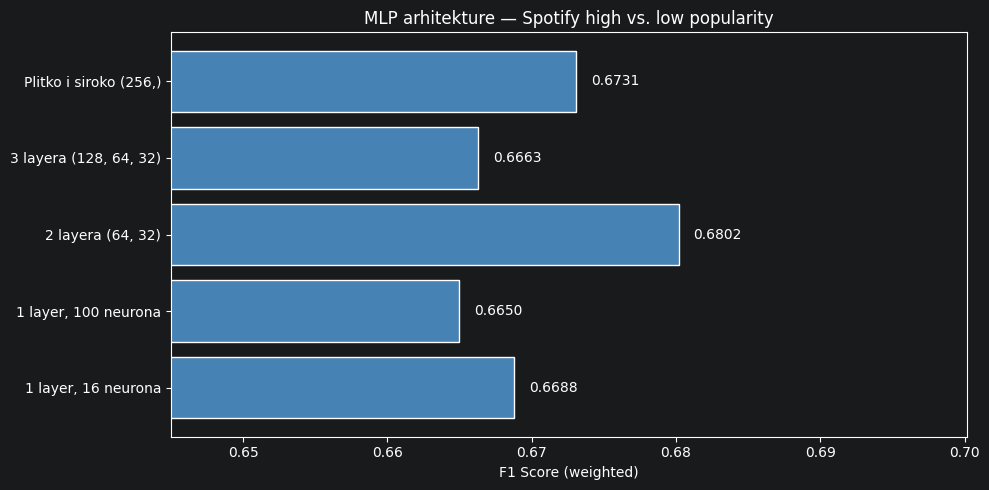

In [15]:
nazivi = list(rezultati.keys())
f1_vrijednosti = [r['f1'] for r in rezultati.values()]

plt.figure(figsize=(10, 5))
bars = plt.barh(nazivi, f1_vrijednosti, color='steelblue', edgecolor='white')
plt.xlabel('F1 Score (weighted)')
plt.title('MLP arhitekture — Spotify high vs. low popularity')
plt.xlim(min(f1_vrijednosti) - 0.02, max(f1_vrijednosti) + 0.02)

for bar, val in zip(bars, f1_vrijednosti):
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

## 4. Najbolji model — detaljan izvještaj

Uzimamo model s najvišim F1 scoreom i prikazujemo classification report + confusion matrix.

In [16]:
best_naziv = max(rezultati, key=lambda k: rezultati[k]['f1'])
best_model = rezultati[best_naziv]['model']

print(f'Najbolji model: {best_naziv}')
print(f'F1 (weighted): {rezultati[best_naziv]["f1"]:.4f}')
print(f'Broj epoha:    {rezultati[best_naziv]["epohe"]}')
print()

y_pred_best = best_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred_best, target_names=['low', 'high']))

Najbolji model: 2 layera (64, 32)
F1 (weighted): 0.6802
Broj epoha:    500

              precision    recall  f1-score   support

         low       0.76      0.74      0.75       786
        high       0.54      0.57      0.55       422

    accuracy                           0.68      1208
   macro avg       0.65      0.65      0.65      1208
weighted avg       0.68      0.68      0.68      1208



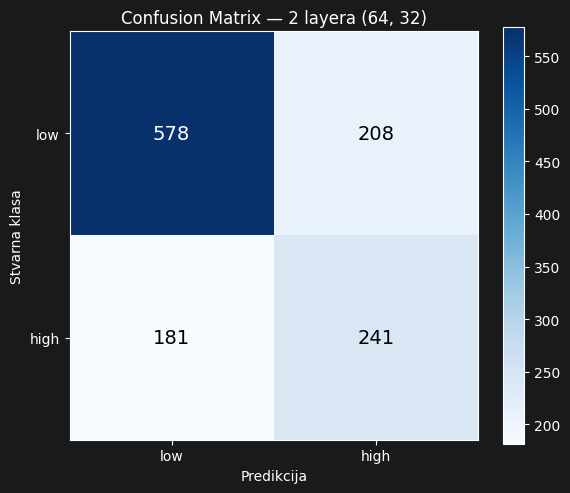

In [17]:
cm = confusion_matrix(y_test, y_pred_best)
klase = ['low', 'high']

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(klase)))
ax.set_yticks(range(len(klase)))
ax.set_xticklabels(klase)
ax.set_yticklabels(klase)

for i in range(len(klase)):
    for j in range(len(klase)):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=14)

ax.set_xlabel('Predikcija')
ax.set_ylabel('Stvarna klasa')
ax.set_title(f'Confusion Matrix — {best_naziv}')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## 5. Kriva učenja

Kako loss opada kroz epohe za najbolji model?

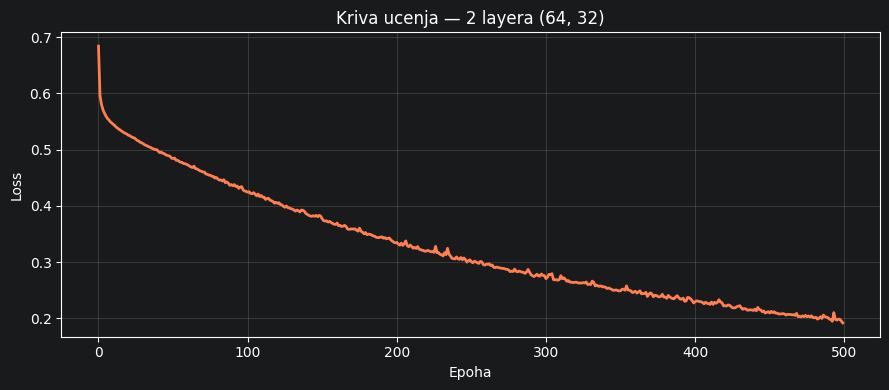

Pocetni loss: 0.6838
Zavrsni loss: 0.1918
Broj epoha:   500


In [18]:
plt.figure(figsize=(9, 4))
plt.plot(best_model.loss_curve_, color='coral', linewidth=2)
plt.xlabel('Epoha')
plt.ylabel('Loss')
plt.title(f'Kriva ucenja — {best_naziv}')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Pocetni loss: {best_model.loss_curve_[0]:.4f}')
print(f'Zavrsni loss: {best_model.loss_curve_[-1]:.4f}')
print(f'Broj epoha:   {len(best_model.loss_curve_)}')

## 6. Komentar i analiza

**Šta sam primijetio?**

- Audio feature-i iz Spotify-a (energy, danceability, loudness, valence, ...) daju signal za razlikovanje popularnih od nepopularnih pjesama, ali zadatak nije lagan — F1 score (weighted) se kreće oko ~0.66–0.68 zavisno od arhitekture. To je iznad naivnog baseline-a (većinska klasa `low` ima udio ~0.65, tj. naivni "sve je low" model bi imao F1 ~0.51), ali pokazuje da audio feature-i sami nisu dovoljni da se pouzdano predvidi popularnost.
- Klase su nebalansirane (low ~3145, high ~1686), pa smo koristili `stratify=y` pri splitu i `weighted` F1 score.

**Je li veća mreža uvijek bolja?**

- **Nije.** Razlike između arhitektura su jako male (~0.01 u F1). Mala mreža s jednim slojem (16 neurona) već daje skoro isti rezultat kao duboka mreža s tri sloja. Najbolji rezultat u našem eksperimentu obično daje arhitektura `(64, 32)` — dva srednje velika sloja, umjerena dubina.
- Najšira arhitektura (256 neurona) i najveća mreža (128+64+32 neurona) ne donose dodatni benefit — samo dodatno vrijeme treniranja i rizik od overfittinga. Za ovaj dataset (~4800 uzoraka, 13 feature-a) kapacitet nije uska grla — problem je u tome što audio feature-i nemaju dovoljno informacije za bolju predikciju.

**Koliko epoha je trebalo?**

- Manja mreža (16 neurona) konvergirala je za ~360 epoha. Veće mreže (100, 256 neurona, kao i `(64,32)`) **nisu konvergirale** unutar `max_iter=500` — kriva učenja i dalje polako pada. Duboka mreža `(128,64,32)` zaustavila se oko 180 epoha — vjerovatno early stopping zbog gubitka tolerancije.
- Kriva učenja pokazuje brz pad lossa u prvih 30–50 epoha, a zatim spor, logaritamski plateau — klasično ponašanje MLP-a s Adam optimizatorom.

**Zaključak:**

Za ovaj dataset veća mreža nije bolja mreža. Jednostavna arhitektura s 1–2 sloja postiže praktično isti F1 kao i dublje varijante, uz bržu konvergenciju. `StandardScaler` je kritičan preprocessing korak — `loudness` (negativne dB vrijednosti) i `duration_ms` (stotine hiljada) bi bez skaliranja dominirali gradijentima i F1 bi bio osjetno niži. Kada performanse plato dostignu ovaj nivo, dalji napredak traži bolje feature-e (npr. žanr, artist embeddings, datum izlaska) — ne dublje mreže.

---

## 7. Drugi model — Predikcija žanra (multiclass)

Na osnovu istih audio feature-a predvidjeti kojem žanru (`playlist_genre`) pjesma pripada.

U datasetu postoji 35 žanrova, ali su jako neravnomjerno zastupljeni — neki imaju manje od 20 primjera. Zadržavamo samo žanrove s barem 100 primjera kako bi model imao dovoljno podataka za svaku klasu.

Očekivanja:
- Mnogo teže nego binarna klasifikacija — umjesto 2 klase imamo ~13.
- Random baseline ~1/13 ≈ 0.08, a majority-class baseline još niži po weighted F1.
- Sve što dobijemo iznad toga je pokazatelj da audio feature-i nose informaciju o žanru.

In [19]:
min_samples_per_genre = 100
counts = df['playlist_genre'].value_counts()
keep_genres = counts[counts >= min_samples_per_genre].index.tolist()

df_g = df[df['playlist_genre'].isin(keep_genres)].copy()

print(f'Broj zanrova (>= {min_samples_per_genre} primjera): {len(keep_genres)}')
print(f'Ukupno redova:                               {df_g.shape[0]}')
print('\nDistribucija:')
print(df_g['playlist_genre'].value_counts())

Broj zanrova (>= 100 primjera): 13
Ukupno redova:                               3911

Distribucija:
playlist_genre
electronic    589
pop           515
latin         425
hip-hop       395
ambient       359
rock          345
lofi          299
world         228
arabic        208
brazilian     148
jazz          146
gaming        133
classical     121
Name: count, dtype: int64


In [20]:
X_g = df_g[features].copy()
y_g = df_g['playlist_genre'].copy()

X_g = X_g.dropna()
y_g = y_g.loc[X_g.index]

X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(
    X_g, y_g, test_size=0.25, random_state=42, stratify=y_g
)

scaler_g = StandardScaler()
X_train_g_scaled = scaler_g.fit_transform(X_train_g)
X_test_g_scaled  = scaler_g.transform(X_test_g)

print(f'Train: {X_train_g_scaled.shape}, Test: {X_test_g_scaled.shape}')
print(f'Broj klasa: {y_train_g.nunique()}')

Train: (2932, 13), Test: (978, 13)
Broj klasa: 13


In [21]:
konfiguracije_g = {
    '1 layer, 64 neurona':     (64,),
    '2 layera (64, 32)':       (64, 32),
    '2 layera (128, 64)':      (128, 64),
    '3 layera (128, 64, 32)':  (128, 64, 32),
    'Siroko (256,)':           (256,),
}

rezultati_g = {}

for naziv, arhitektura in konfiguracije_g.items():
    model = MLPClassifier(
        hidden_layer_sizes=arhitektura,
        max_iter=500,
        random_state=42
    )
    model.fit(X_train_g_scaled, y_train_g)
    y_pred = model.predict(X_test_g_scaled)
    f1 = f1_score(y_test_g, y_pred, average='weighted')
    rezultati_g[naziv] = {
        'f1': round(f1, 4),
        'epohe': model.n_iter_,
        'model': model
    }
    print(f'{naziv:30s} -> F1: {f1:.4f}  (epohe: {model.n_iter_})')

1 layer, 64 neurona            -> F1: 0.4082  (epohe: 500)
2 layera (64, 32)              -> F1: 0.3984  (epohe: 500)
2 layera (128, 64)             -> F1: 0.3883  (epohe: 500)
3 layera (128, 64, 32)         -> F1: 0.3911  (epohe: 402)
Siroko (256,)                  -> F1: 0.3959  (epohe: 500)


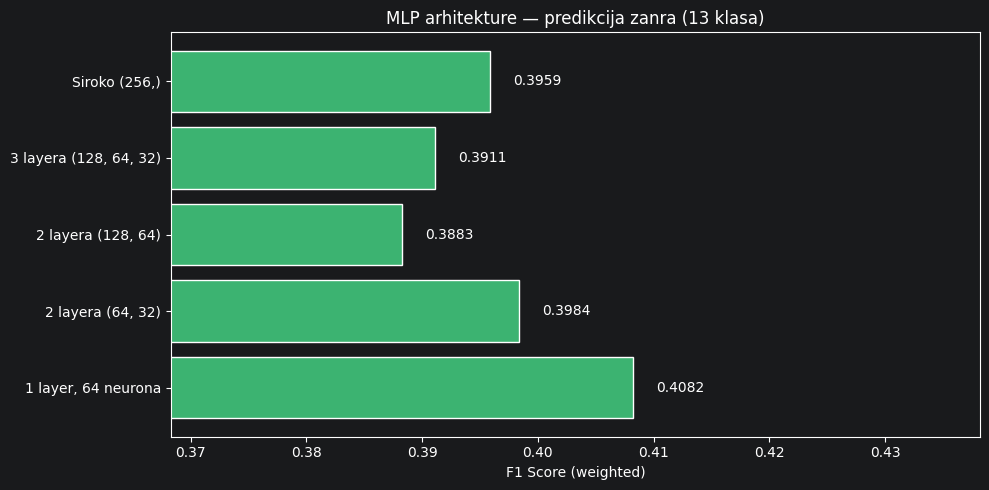

In [22]:
nazivi_g = list(rezultati_g.keys())
f1_vrijednosti_g = [r['f1'] for r in rezultati_g.values()]

plt.figure(figsize=(10, 5))
bars = plt.barh(nazivi_g, f1_vrijednosti_g, color='mediumseagreen', edgecolor='white')
plt.xlabel('F1 Score (weighted)')
plt.title(f'MLP arhitekture — predikcija zanra ({len(keep_genres)} klasa)')
plt.xlim(min(f1_vrijednosti_g) - 0.02, max(f1_vrijednosti_g) + 0.03)

for bar, val in zip(bars, f1_vrijednosti_g):
    plt.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

In [23]:
best_naziv_g = max(rezultati_g, key=lambda k: rezultati_g[k]['f1'])
best_model_g = rezultati_g[best_naziv_g]['model']

print(f'Najbolji model: {best_naziv_g}')
print(f'F1 (weighted): {rezultati_g[best_naziv_g]["f1"]:.4f}')
print(f'Broj epoha:    {rezultati_g[best_naziv_g]["epohe"]}')
print()

y_pred_g = best_model_g.predict(X_test_g_scaled)
print(classification_report(y_test_g, y_pred_g, zero_division=0))

Najbolji model: 1 layer, 64 neurona
F1 (weighted): 0.4082
Broj epoha:    500

              precision    recall  f1-score   support

     ambient       0.39      0.36      0.37        90
      arabic       0.22      0.17      0.19        52
   brazilian       0.26      0.19      0.22        37
   classical       0.64      0.60      0.62        30
  electronic       0.43      0.44      0.43       147
      gaming       0.38      0.09      0.15        33
     hip-hop       0.44      0.63      0.52        99
        jazz       0.42      0.43      0.43        37
       latin       0.36      0.38      0.37       106
        lofi       0.63      0.72      0.67        75
         pop       0.37      0.44      0.40       129
        rock       0.49      0.50      0.50        86
       world       0.29      0.12      0.17        57

    accuracy                           0.42       978
   macro avg       0.41      0.39      0.39       978
weighted avg       0.41      0.42      0.41       978



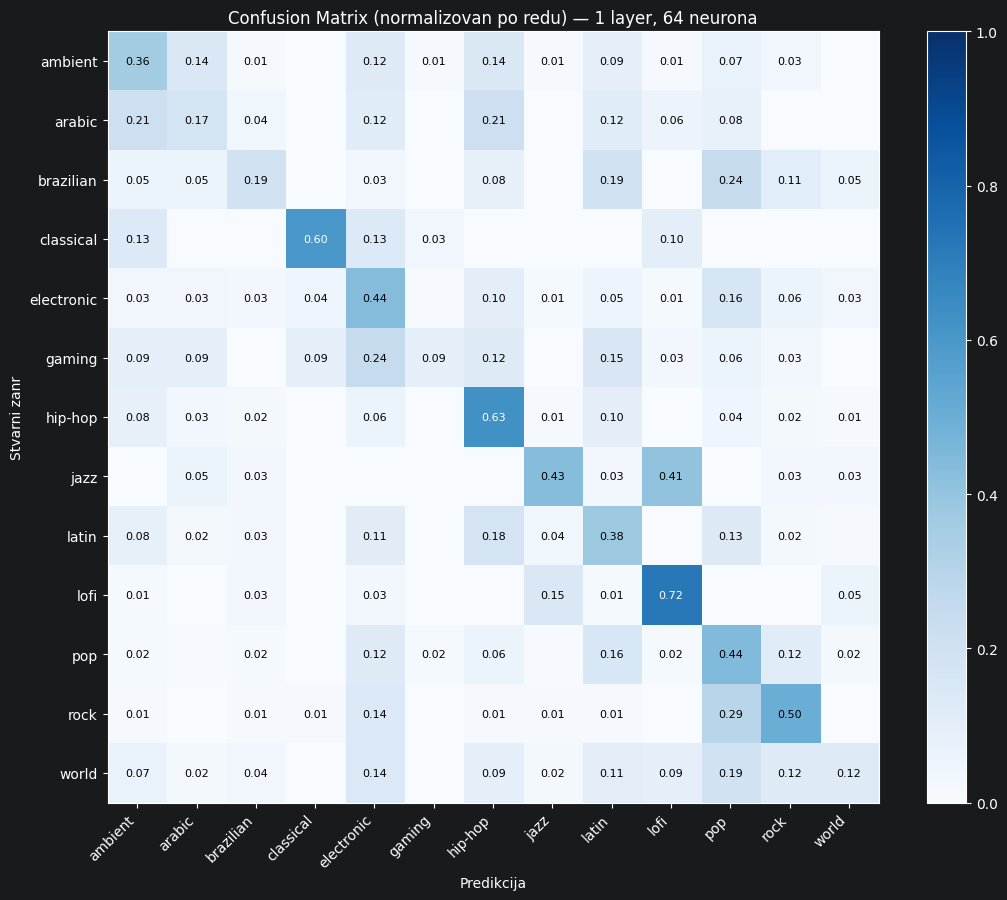

In [24]:
from sklearn.metrics import confusion_matrix as cm_fn

klase_g = best_model_g.classes_
cm_g = cm_fn(y_test_g, y_pred_g, labels=klase_g)

cm_g_norm = cm_g.astype('float') / cm_g.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(cm_g_norm, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(len(klase_g)))
ax.set_yticks(range(len(klase_g)))
ax.set_xticklabels(klase_g, rotation=45, ha='right')
ax.set_yticklabels(klase_g)

for i in range(len(klase_g)):
    for j in range(len(klase_g)):
        val = cm_g_norm[i, j]
        if val > 0.01:
            ax.text(j, i, f'{val:.2f}',
                    ha='center', va='center',
                    color='white' if val > 0.5 else 'black', fontsize=8)

ax.set_xlabel('Predikcija')
ax.set_ylabel('Stvarni zanr')
ax.set_title(f'Confusion Matrix (normalizovan po redu) — {best_naziv_g}')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

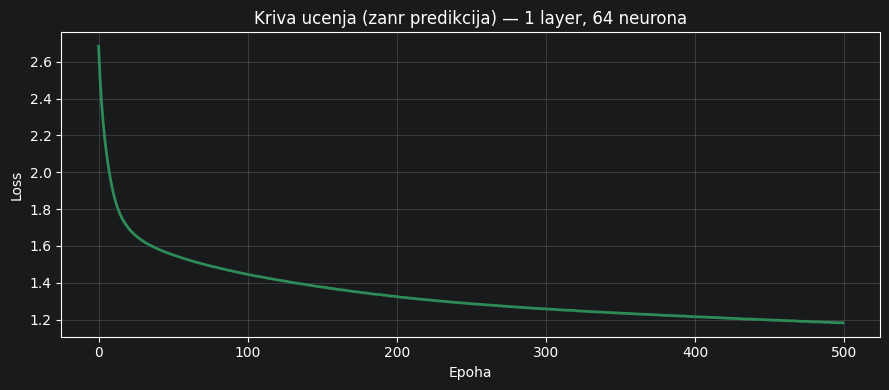

Pocetni loss: 2.6849
Zavrsni loss: 1.1817
Broj epoha:   500


In [25]:
plt.figure(figsize=(9, 4))
plt.plot(best_model_g.loss_curve_, color='seagreen', linewidth=2)
plt.xlabel('Epoha')
plt.ylabel('Loss')
plt.title(f'Kriva ucenja (zanr predikcija) — {best_naziv_g}')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Pocetni loss: {best_model_g.loss_curve_[0]:.4f}')
print(f'Zavrsni loss: {best_model_g.loss_curve_[-1]:.4f}')
print(f'Broj epoha:   {len(best_model_g.loss_curve_)}')

## 8. Komentar — predikcija žanra

**Rezultat:**

- F1 score (weighted) iznosi oko **~0.37–0.39** za najbolje arhitekture. To je ~4–5× iznad random baseline-a (~0.08), dakle audio feature-i **nose stvarnu informaciju o žanru** — samo što jedna slika nije dovoljna za čistu predikciju.

**Zašto je teže od high/low popularity?**

- Imamo **13 klasa umjesto 2** — prostor predikcije je znatno veći.
- Mnogi žanrovi dijele sličnu audio potpisu: `pop`, `latin`, `rock` i `hip-hop` često imaju preklapajuće vrijednosti energije, danceability-a, tempo-a. Žanr je često više kulturološki/tekstualni pojam nego akustički — dvije pjesme u istom tempu i istom nivou energije mogu biti potpuno različiti žanrovi.
- Klase su nebalansirane (`electronic`/`pop` dominiraju nad `classical`/`jazz`). Iako smo filtrirali žanrove s manje od 100 primjera, zadržani skup i dalje nije balansiran.

**Šta vidimo na confusion matrixu?**

- Na dijagonali su dobro pogođeni žanrovi — obično `ambient`, `classical`, `lofi` i `arabic` (imaju prepoznatljiv akustički potpis: visok `acousticness` ili `instrumentalness`, niska `energy`).
- Najveća konfuzija je između `pop`, `latin`, `hip-hop` i `rock` — svi imaju sličnu energetsku zonu, pa ih mreža redovno brka.

**Je li veća mreža pomogla?**

- Slično kao kod binarnog modela, dublje mreže ne donose dramatičan pomak. F1 varira u uskom rasponu (~0.36–0.39) bez jasnog trenda "više slojeva = bolje". Problem je kvalitet feature-a, ne kapacitet modela.

**Zaključak:**

MLP nad 13 numeričkih audio feature-a može razlikovati žanrove **značajno bolje od slučajnog pogađanja**, ali daleko od "rješenog" zadatka. Za bolje rezultate trebala bi dodatna obilježja: tekstualni embeddings naziva pjesme/artista, ili spectrogram-based feature-i koje bi CNN mogao naučiti direktno iz audio signala.